In [1]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 44.5 MB/s eta 0:00:00


In [2]:
from faker import Faker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
fake = Faker()
names = [fake.name() for _ in range(1000)]

In [4]:
np.random.seed(42)
n = 250

data = {
    "Student_ID": np.arange(1, n+1),
    "Name": np.random.choice(names, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Department": np.random.choice(["CSE", "IT", "ECE"], n),
    "Year": np.random.choice(["1st", "2nd", "3rd"], n),
    "Maths": np.random.randint(40, 100, n),
    "Science": np.random.randint(40, 100, n),
    "English": np.random.randint(40, 100, n),
    "Attendance": np.random.randint(50, 100, n),
    "Internal_Marks": np.random.randint(0, 25, n)
}

In [5]:
df = pd.DataFrame(data)

In [6]:
df["Total"] = df["Maths"] + df["Science"] + df["English"]
df["Average"] = df["Total"] / 3

In [7]:
df["Grade"] = df["Average"].apply(lambda x: "A" if x>=85 else "B" if x>=70 else "C" if x>=50 else "Fail")

In [8]:
df

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks,Total,Average,Grade
0,1,Christine Garcia,Male,IT,3rd,41,99,52,51,23,192,64.000000,C
1,2,Neil Rodriguez,Male,CSE,2nd,52,83,69,58,7,204,68.000000,C
2,3,Joseph Warner,Female,IT,3rd,82,89,62,58,1,233,77.666667,B
3,4,Jeffrey Keith,Male,ECE,2nd,82,53,90,89,7,225,75.000000,B
4,5,Micheal Vaughn,Male,IT,1st,87,92,98,66,12,277,92.333333,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,246,Anthony Crane,Male,ECE,1st,74,79,84,89,11,237,79.000000,B
246,247,Scott Gardner,Male,CSE,1st,69,88,82,94,7,239,79.666667,B
247,248,Lisa Lopez,Female,CSE,2nd,70,46,73,81,7,189,63.000000,C
248,249,Christopher Perez,Male,IT,2nd,88,40,48,78,17,176,58.666667,C


data cleaning and preprocessing

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      250 non-null    int64  
 1   Name            250 non-null    object 
 2   Gender          250 non-null    object 
 3   Department      250 non-null    object 
 4   Year            250 non-null    object 
 5   Maths           250 non-null    int64  
 6   Science         250 non-null    int64  
 7   English         250 non-null    int64  
 8   Attendance      250 non-null    int64  
 9   Internal_Marks  250 non-null    int64  
 10  Total           250 non-null    int64  
 11  Average         250 non-null    float64
 12  Grade           250 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 25.5+ KB


In [10]:
df.isnull().sum()

,0
Student_ID,0
Name,0
Gender,0
Department,0
Year,0
Maths,0
Science,0
English,0
Attendance,0
Internal_Marks,0


descriptive statistics

In [11]:
df.mean(numeric_only=True)

,0
Student_ID,125.500000
Maths,68.268000
Science,70.044000
English,70.660000
Attendance,75.060000
Internal_Marks,11.636000
Total,208.972000
Average,69.657333


In [12]:
df.median(numeric_only=True)

,0
Student_ID,125.5
Maths,67.0
Science,71.5
English,71.0
Attendance,74.0
Internal_Marks,12.0
Total,207.0
Average,69.0


In [13]:
df.describe()

,Student_ID,Maths,Science,English,Attendance,Internal_Marks,Total,Average
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,125.500000,68.268000,70.044000,70.660000,75.060000,11.636000,208.972000,69.657333
std,72.312977,17.633831,16.848071,17.177797,14.638084,6.970355,29.810432,9.936811
min,1.000000,40.000000,40.000000,40.000000,50.000000,0.000000,128.000000,42.666667
25%,63.250000,53.000000,56.000000,57.250000,62.000000,6.000000,191.000000,63.666667
50%,125.500000,67.000000,71.500000,71.000000,74.000000,12.000000,207.000000,69.000000
75%,187.750000,84.000000,84.000000,85.750000,88.000000,17.000000,230.000000,76.666667
max,250.000000,99.000000,99.000000,99.000000,99.000000,24.000000,278.000000,92.666667


In [14]:
df.mode()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks,Total,Average,Grade
0,1,Jennifer Fleming,Female,CSE,1st,65.0,79.0,62.0,74.0,14.0,193.0,64.333333,C
1,2,NaN,NaN,NaN,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246,247,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
247,248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
248,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.std(numeric_only=True)

,0
Student_ID,72.312977
Maths,17.633831
Science,16.848071
English,17.177797
Attendance,14.638084
Internal_Marks,6.970355
Total,29.810432
Average,9.936811


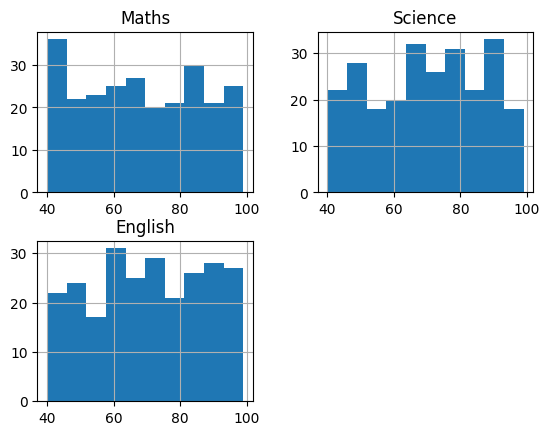

In [16]:
df[["Maths","Science","English"]].hist()
plt.show()

student performance metrics

In [17]:
df.Total

,Total
0,192
1,204
2,233
3,225
4,277
...,...
245,237
246,239
247,189
248,176


In [18]:
df.Average

,Average
0,64.000000
1,68.000000
2,77.666667
3,75.000000
4,92.333333
...,...
245,79.000000
246,79.666667
247,63.000000
248,58.666667


In [19]:
df.Grade

,Grade
0,C
1,C
2,B
3,B
4,A
...,...
245,B
246,B
247,C
248,C


top-performing students and low-performing

In [20]:
top_mark=df.sort_values(by = "Total", ascending=False).head(5)
top_mark

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks,Total,Average,Grade
185,186,Renee Leach,Female,CSE,1st,88,94,96,96,13,278,92.666667,A
4,5,Micheal Vaughn,Male,IT,1st,87,92,98,66,12,277,92.333333,A
152,153,Jennifer Webb,Female,ECE,1st,92,87,93,64,2,272,90.666667,A
29,30,Dawn Hunt,Male,IT,1st,97,98,77,96,22,272,90.666667,A
62,63,Matthew Miller,Male,ECE,1st,87,90,93,56,21,270,90.000000,A


In [21]:
fail_students = df[df["Grade"] == "Fail"]
fail_students

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks,Total,Average,Grade
17,18,Ray Bell,Male,IT,2nd,43,47,57,93,12,147,49.000000,Fail
32,33,Cynthia Miller,Male,IT,1st,60,43,40,73,10,143,47.666667,Fail
39,40,Richard Miller,Male,ECE,1st,45,47,49,86,12,141,47.000000,Fail
66,67,Heather Burnett,Female,CSE,1st,40,46,42,58,17,128,42.666667,Fail
112,113,Nicole Jackson,Female,ECE,2nd,61,43,41,83,21,145,48.333333,Fail
183,184,Kayla Williamson,Male,IT,3rd,45,40,60,54,17,145,48.333333,Fail
191,192,Jason Wyatt,Female,ECE,3rd,41,48,51,98,0,140,46.666667,Fail
204,205,David Roberts,Male,CSE,2nd,58,50,41,74,14,149,49.666667,Fail


Group-based analysis

In [22]:
df.groupby("Department")[["Maths","Science","English","Total","Average"]].mean()

,Maths,Science,English,Total,Average
Department,,,,,
CSE,66.318681,71.021978,69.065934,206.406593,68.802198
ECE,67.794521,70.575342,74.602740,212.972603,70.990868
IT,70.732558,68.558140,69.000000,208.290698,69.430233


In [23]:
df.groupby("Gender")[["Maths","Science","English","Total","Average"]].mean()

,Maths,Science,English,Total,Average
Gender,,,,,
Female,68.633588,70.458015,71.358779,210.450382,70.150127
Male,67.865546,69.588235,69.890756,207.344538,69.114846


In [24]:
df.groupby("Year")[["Maths","Science","English","Total","Average"]].mean()

,Maths,Science,English,Total,Average
Year,,,,,
1st,67.631579,71.263158,70.936842,209.831579,69.943860
2nd,67.590361,68.132530,71.144578,206.867470,68.955823
3rd,69.888889,70.638889,69.736111,210.263889,70.087963


relationship between variables

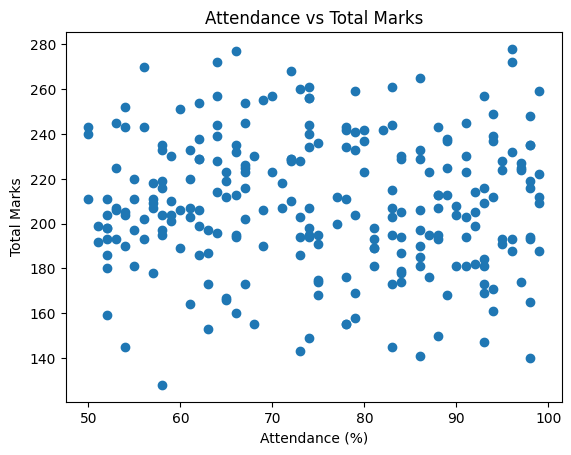

In [25]:
import matplotlib.pyplot as plt

plt.scatter(df["Attendance"], df["Total"])
plt.title("Attendance vs Total Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Total Marks")
plt.show()

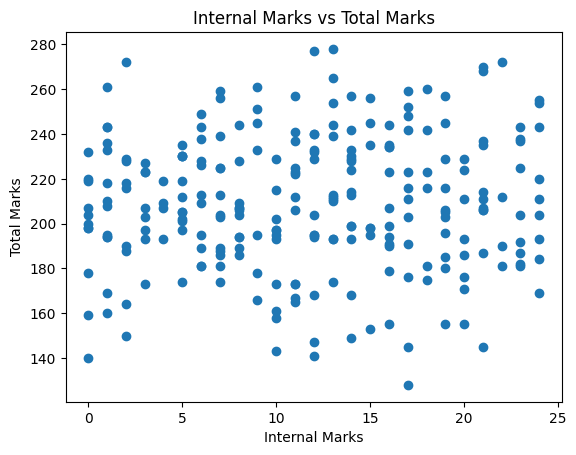

In [26]:
plt.scatter(df["Internal_Marks"], df["Total"])
plt.title("Internal Marks vs Total Marks")
plt.xlabel("Internal Marks")
plt.ylabel("Total Marks")
plt.show()

 visualize the data using graphs and charts

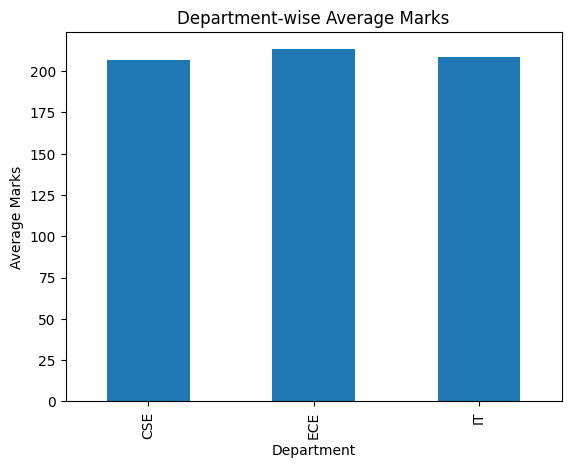

In [27]:
import matplotlib.pyplot as plt

df.groupby("Department")["Total"].mean().plot(kind="bar")
plt.title("Department-wise Average Marks")
plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.show()

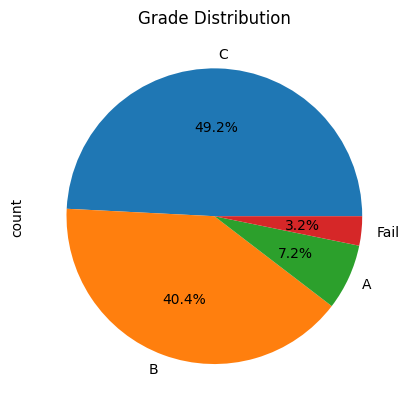

In [28]:
df["Grade"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Grade Distribution")
plt.show()

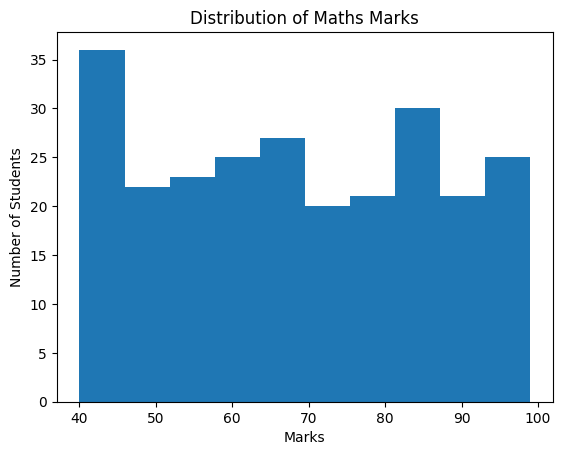

In [29]:
plt.hist(df["Maths"])
plt.title("Distribution of Maths Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.show()

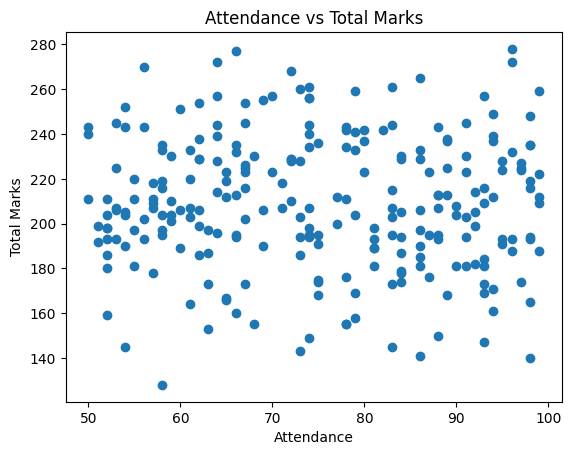

In [30]:
plt.scatter(df["Attendance"], df["Total"])
plt.title("Attendance vs Total Marks")
plt.xlabel("Attendance")
plt.ylabel("Total Marks")
plt.show()

•	To derive meaningful insights and conclusions that can help in improving student performance and academic decision-making.